In [1]:
import math
from scipy.stats import pearsonr
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
import concurrent.futures

In [3]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850-raw-wmeta.h5ad'
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 3938808 × 550
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x', 'y', 'z', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color'
    var: 'gene_symbol', 'transcript_identifier'
    uns: 'accessed_on', 'src'

In [12]:
# subsetting to one section
adata = adata[adata.obs['brain_section_label'] == 'C57BL6J-638850.38'].copy()
adata

AnnData object with n_obs × n_vars = 120186 × 550
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x', 'y', 'z', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color'
    var: 'gene_symbol', 'transcript_identifier'
    uns: 'accessed_on', 'src'

In [4]:
modules_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-modules.csv",
    index_col = "Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_green,kME_brown,kME_grey,kME_blue,kME_turquoise,kME_yellow,kME_red
ENSMUSG00000015090,ENSMUSG00000015090,green,green,0.653472,-0.032236,-0.115646,0.123502,0.069904,0.154395,-0.175664
ENSMUSG00000031425,ENSMUSG00000031425,green,green,0.921549,-0.047739,-0.106292,0.077948,0.088522,0.202247,-0.212231
ENSMUSG00000115529,ENSMUSG00000115529,green,green,0.283788,-0.010976,-0.029480,0.021220,0.017650,0.086082,-0.085927
ENSMUSG00000029819,ENSMUSG00000029819,brown,brown,-0.017231,0.547982,-0.066836,-0.008960,-0.004381,0.005224,-0.110663
ENSMUSG00000024610,ENSMUSG00000024610,grey,grey,0.007531,-0.025541,-0.034615,0.028825,0.155726,0.004847,-0.031323


In [5]:
merfish_panel_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/gene_panel.csv"
)
merfish_panel_df.head()

,gene_identifier,gene_symbol,transcript_identifier
0,ENSMUSG00000026778,Prkcq,ENSMUST00000028118
1,ENSMUSG00000026837,Col5a1,ENSMUST00000028280
2,ENSMUSG00000001985,Grik3,ENSMUST00000030676
3,ENSMUSG00000039323,Igfbp2,ENSMUST00000047328
4,ENSMUSG00000048387,Osr1,ENSMUST00000057021


In [6]:
# Getting all module names
all_modules = modules_df["color"].unique().tolist()

## No permutation

In [ ]:
# Prepare a list to hold results for each module.
results = []

for select_module in set(all_modules) - {"grey"}:
    # ME for the whole module
    print("Current module: ", select_module)
    select_genes = modules_df[modules_df["module"] == select_module].index
    print("Number of genes in the module: ", select_genes.shape[0])
    common_genes = adata.var_names.intersection(select_genes)
    adata_subset = adata[:,common_genes].copy()
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)
    sc.pp.scale(adata_subset, max_value=10)
    sc.tl.pca(adata_subset, n_comps = 2, svd_solver="arpack")
    adata_subset.obs[select_module] = adata_subset.obsm['X_pca'][:,0]

    # Tau score for whole module
    tau_full_df = adata_subset.obs[["class"]].copy()
    tau_full_df[select_module] = adata_subset.obsm['X_pca'][:,0]
    tau_full_df[select_module] = tau_full_df[select_module] - tau_full_df[select_module].min() + 1e-6
    avg_expression = tau_full_df.groupby('class')[select_module].mean()
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr
    tau_full = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)

    results.append({
        "module": select_module,
        "n_MERFISH_genes": common_genes.shape[0],
        "observed_tau": tau_full
    })
    
    del adata_subset

results_df = pd.DataFrame(results)
print(results_df)

# With permutation

In [8]:
# Function to compute Tau score from an AnnData object that has PCA computed
def compute_tau(adata_obj, module_obs_key):
    # Create a DataFrame with cell class and the module eigengene value
    tau_df = adata_obj.obs[['class']].copy()
    tau_df[module_obs_key] = adata_obj.obsm['X_pca'][:, 0]
    # Shift the values to be positive
    tau_df[module_obs_key] = tau_df[module_obs_key] - tau_df[module_obs_key].min() + 1e-6
    # Compute average expression per class
    avg_expression = tau_df.groupby('class')[module_obs_key].mean()
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr
    # Compute Tau: tau = sum(1 - normalized_expr)/(number_of_classes - 1)
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    return tau

In [9]:
# Define a function for one permutation iteration.
def permutation_tau(seed):
    # Set the random seed for reproducibility in this process.
    np.random.seed(seed)
    # Randomly sample genes without replacement
    random_genes = np.random.choice(all_genes, size=n_genes_in_module, replace=False)
    # Create a copy of adata for the selected genes
    adata_perm = adata[:, random_genes].copy()
    
    # Preprocess the subset (normalization, log transform, scaling, PCA)
    sc.pp.normalize_total(adata_perm, target_sum=1e4)
    sc.pp.log1p(adata_perm)
    sc.pp.scale(adata_perm, max_value=10)
    sc.tl.pca(adata_perm, n_comps=2, svd_solver="arpack")
    
    # Store the first principal component as the temporary module eigengene
    temp_key = "temp_module"
    adata_perm.obs[temp_key] = adata_perm.obsm['X_pca'][:, 0]
    
    # Compute and return the Tau score for this random gene set.
    return compute_tau(adata_perm, temp_key)

**One module**

Number of genes in module yellow: 181


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


Observed Tau score for module yellow: 0.287


/tmp/ipykernel_631205/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_631205/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_631205/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[

Permutation test p-value: 0.000


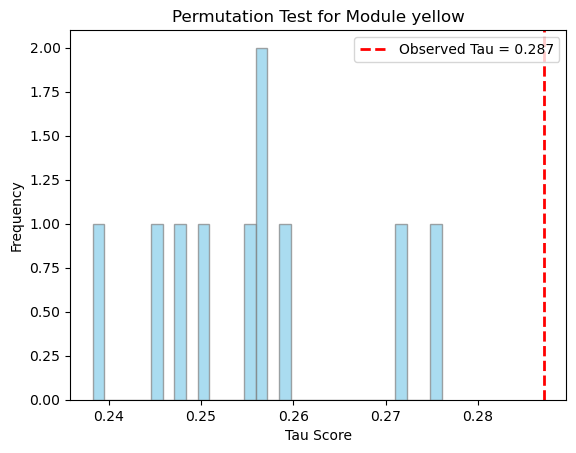

In [15]:
# Parameters
n_permutations = 10  # number of random permutations
module_name = 'yellow'  # change this to the module you want to test

# Observed: Select the genes that belong to your module
select_genes = modules_df[modules_df["module"] == module_name].index
n_genes_in_module = select_genes.shape[0]
print(f"Number of genes in module {module_name}: {n_genes_in_module}")

# Compute the observed Tau score for the whole module
common_genes = adata.var_names.intersection(select_genes)
adata_subset = adata[:, common_genes]

# Preprocess: normalization, log, scaling, PCA
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")

# Store the eigengene in obs with a key (here, we use the module name)
adata_subset.obs[module_name] = adata_subset.obsm['X_pca'][:, 0]
observed_tau = compute_tau(adata_subset, module_name)
print(f"Observed Tau score for module {module_name}: {observed_tau:.3f}")

# Get the list of all genes from the AnnData object
all_genes = adata.var_names

# Prepare random seeds for each permutation for reproducibility
seeds = np.random.randint(0, 1000000, size=n_permutations)

# Run the permutation iterations in parallel using ProcessPoolExecutor.
with concurrent.futures.ProcessPoolExecutor() as executor:
    tau_null = list(executor.map(permutation_tau, seeds))

tau_null = np.array(tau_null)

# Compute the p-value: proportion of permutations with Tau score >= observed_tau.
p_value = np.mean(tau_null >= observed_tau)
print(f"Permutation test p-value: {p_value:.3f}")

# Plot the null distribution with the observed Tau score
plt.hist(tau_null, bins=30, alpha=0.7, color='skyblue', edgecolor='gray')
plt.axvline(observed_tau, color='red', linestyle='dashed', linewidth=2,
            label=f'Observed Tau = {observed_tau:.3f}')
plt.xlabel("Tau Score")
plt.ylabel("Frequency")
plt.title(f"Permutation Test for Module {module_name}")
plt.legend()
plt.show()

**All modules**

In [ ]:
# Parameters
n_permutations = 3  # number of random permutations

# Prepare a list to hold results for each module.
results = []

# Getting all module names
all_modules = modules_df["color"].unique().tolist()

for module_name in set(all_modules) - {"grey"}:

    # Observed: Select the genes that belong to your module
    select_genes = modules_df[modules_df["module"] == module_name].index
    n_genes_in_module = select_genes.shape[0]
    print(f"Number of genes in module {module_name}: {n_genes_in_module}")

    # Compute the observed Tau score for the whole module
    common_genes = adata.var_names.intersection(select_genes)
    adata_subset = adata[:, common_genes].copy()

    # Preprocess: normalization, log, scaling, PCA
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)
    sc.pp.scale(adata_subset, max_value=10)
    sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")

    # Store the eigengene in obs with a key (here, we use the module name)
    adata_subset.obs[module_name] = adata_subset.obsm['X_pca'][:, 0]
    observed_tau = compute_tau(adata_subset, module_name)
    print(f"Observed Tau score for module {module_name}: {observed_tau:.3f}")

    # Get the list of all genes from the AnnData object
    all_genes = adata.var_names

    # Prepare random seeds for each permutation for reproducibility
    seeds = np.random.randint(0, 1000000, size=n_permutations)

    # Run the permutation iterations in parallel using ProcessPoolExecutor.
    with concurrent.futures.ProcessPoolExecutor() as executor:
        tau_null = list(executor.map(permutation_tau, seeds))

    tau_null = np.array(tau_null)

    # Compute the p-value: proportion of permutations with Tau score >= observed_tau.
    r = np.sum(tau_null >= observed_tau)
    p_value = (r + 1) / (n_permutations + 1)
    print(f"Permutation test p-value: {p_value:.5f}")

    results.append({
        "module": module_name,
        "n_MERFISH_genes": n_genes_in_module,
        "MERFISH_tau": observed_tau,
        "p_value": p_value
    })

results_df = pd.DataFrame(results)
print(results_df)

Number of genes in module brown: 192


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


Observed Tau score for module brown: 0.328


/tmp/ipykernel_345583/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_345583/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_345583/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[

Permutation test p-value: 0.25000
Number of genes in module blue: 193
Observed Tau score for module blue: 0.581


...

Permutation test p-value: 0.25000
Number of genes in module yellow: 181


/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


Observed Tau score for module yellow: 0.273


/tmp/ipykernel_345583/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_345583/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[module_obs_key].mean()
/tmp/ipykernel_345583/3469756114.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[

Permutation test p-value: 0.75000
      module  n_total_genes  observed_tau  p_value
0      brown            192      0.328478     0.25
1       blue            193      0.581002     0.25
2  turquoise            194      0.564744     0.25
3        red             93      0.311980     0.25
4      green            119      0.532293     0.25
5     yellow            181      0.272935     0.75
